|Model|Pipeline (Weights only)  | Transformer (Weights only) | Transformer Inference  |
|---|:---:|:---:|:---:|
| SD 3 Medium | 16.3 | 3.9  | 4.26 |   
| SD 3.5 Medium  | 19.8  | 4.63  | 4.98  |   
| SD 3.5 Large Turbo | -  | 15.56  | 15.80  |   
| PixArt-sigma-XL | 12.2  | 1.16  | 1.37 |   
| Flux Schnell | 31.4  | 22.16  |  22.57  |   
| Flux Dev | 31.4  | 22.18  |  22.61  |   
| Sana 1.6B | 8.5  |  3.05 | 3.25  |   
| KOALA 1.1B | -  |  2.2 | 2.51  |   

# Memory Analysis with Pytorch Profiler

In [1]:
import json
from pathlib import Path
import gc
import torch
import matplotlib.pyplot as plt


def get_memory_samples_from_json(path: str):

    with open(path, "r") as f:
        data = json.load(f)

    events = data["traceEvents"]
    # get only [memory] events
    mem_events = filter(lambda events: events["name"] == "[memory]", events)
    # extract memory allocated in each event
    memory = [mem["args"]["Total Allocated"] for mem in mem_events]

    return memory


# Display memory peak
def display_memory_peak(log_dir, verbose=False):
    jsons_generated = list(Path(log_dir).glob("*.json"))
    for i, jj in enumerate(jsons_generated):
        memory = get_memory_samples_from_json(jj)
        peak = max(memory)
        print(f"Repeat #{i}:{jj} --> memory peak: {peak/(1024**3):.2f} GB")
        if verbose:
            print(f"Raw data of memory foorprint: {memory}")
    # return the last measured peak
    return peak, memory

## SD3.5 Medium
#### Load transformer module and measure the inference memory

/home/yd.kwon/miniconda3/envs/py311/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[INFO] Before loading transformer, allocated memory 0.0
[INFO] After loading transformer, allocated memory 4.633842945098877
[INFO] Before running transformer, allocated memory 4.639908790588379
[INFO] Before running transformer, MAX allocated memory 4.639908790588379


/home/yd.kwon/miniconda3/envs/py311/lib/python3.11/site-packages/torch/profiler/profiler.py:445: UserWarning: Profiler won't be using warmup, this can skew profiler results
  warn("Profiler won't be using warmup, this can skew profiler results")


[INFO] After running transformer, allocated memory 4.648819923400879
[INFO] After running transformer, MAX allocated memory 4.981919288635254
Repeat #0:log/SD35_medium/inst-ahqiy-samsung-rdma-pool_2393905.1734636643150200712.pt.trace.json --> memory peak: 4.98 GB
[INFO] After removing transformer, allocated memory 0.014976978302001953
[INFO] After removing transformer, MAX allocated memory 0.014976978302001953


/home/yd.kwon/miniconda3/envs/py311/lib/python3.11/site-packages/torch/cuda/memory.py:365: FutureWarning: torch.cuda.reset_max_memory_allocated now calls torch.cuda.reset_peak_memory_stats, which resets /all/ peak memory stats.
  warnings.warn(


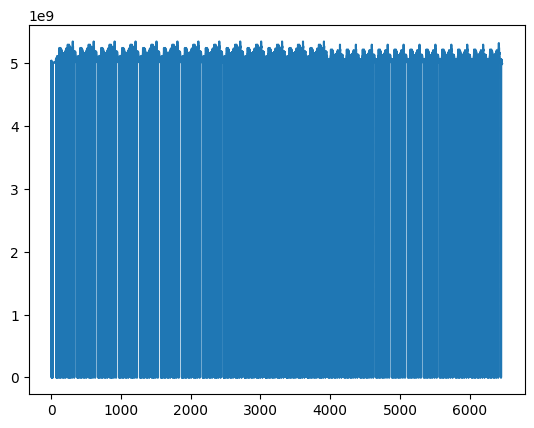

In [2]:
from diffusers import SD3Transformer2DModel

### User Inputs Below
name = "stabilityai/stable-diffusion-3.5-medium"
log_dir = f"./log/SD35_medium"
cfg_dim = 1 if "turbo" in name else 2
### User Inputs Above

print(
    f"[INFO] Before loading transformer, allocated memory {torch.cuda.memory_allocated(0)/1024**3}"
)
transformer = SD3Transformer2DModel.from_pretrained(
    name, subfolder="transformer", torch_dtype=torch.bfloat16
)
transformer = transformer.to("cuda:0")
print(
    f"[INFO] After loading transformer, allocated memory {torch.cuda.memory_allocated(0)/1024**3}"
)

latent_model_input = torch.rand([cfg_dim, 16, 128, 128], dtype=torch.bfloat16).to("cuda:0")
timestep = torch.rand([cfg_dim]).to("cuda:0", dtype=torch.bfloat16)
prompt_embeds = torch.rand([cfg_dim, 333, 4096], dtype=torch.bfloat16).to("cuda:0")
pooled_prompt_embeds = torch.rand([cfg_dim, 2048], dtype=torch.bfloat16).to("cuda:0")
print(
    f"[INFO] Before running transformer, allocated memory {torch.cuda.memory_allocated(0)/1024**3}"
)
print(
    f"[INFO] Before running transformer, MAX allocated memory {torch.cuda.max_memory_allocated(0)/1024**3}"
)

with torch.profiler.profile(
    schedule=torch.profiler.schedule(wait=0, warmup=0.0, active=100, repeat=10),
    on_trace_ready=torch.profiler.tensorboard_trace_handler(log_dir),
    record_shapes=True,
    with_flops=True,
    profile_memory=True,
    with_stack=True,
) as prof:

    with torch.no_grad():
        noise_pred = transformer(
            hidden_states=latent_model_input,
            timestep=timestep,
            encoder_hidden_states=prompt_embeds,
            pooled_projections=pooled_prompt_embeds,
            joint_attention_kwargs=None,
            return_dict=False,
        )[0]
print(
    f"[INFO] After running transformer, allocated memory {torch.cuda.memory_allocated(0)/1024**3}"
)
print(
    f"[INFO] After running transformer, MAX allocated memory {torch.cuda.max_memory_allocated(0)/1024**3}"
)

peak, memory = display_memory_peak(log_dir)
plt.plot(memory)
del transformer
torch.cuda.empty_cache()
gc.collect()
torch.cuda.reset_max_memory_allocated()

print(
    f"[INFO] After removing transformer, allocated memory {torch.cuda.memory_allocated(0)/1024**3}"
)
print(
    f"[INFO] After removing transformer, MAX allocated memory {torch.cuda.max_memory_allocated(0)/1024**3}"
)

## SD3 Medium

[INFO] Before loading transformer, allocated memory 0.014976978302001953
[INFO] After loading transformer, allocated memory 3.944399833679199
[INFO] Before running transformer, allocated memory 3.944399833679199
[INFO] Before running transformer, MAX allocated memory 3.9494810104370117
[INFO] After running transformer, allocated memory 3.944399833679199
[INFO] After running transformer, MAX allocated memory 4.254986763000488
Repeat #0:log/SD3_medium/inst-ahqiy-samsung-rdma-pool_2393905.1734636656325841851.pt.trace.json --> memory peak: 4.25 GB
[INFO] After removing transformer, allocated memory 0.014976978302001953
[INFO] After removing transformer, MAX allocated memory 0.014976978302001953


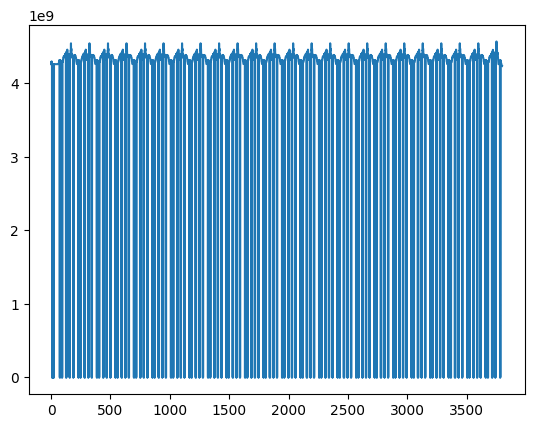

In [3]:
from diffusers import SD3Transformer2DModel

### User Inputs Below
name = "stabilityai/stable-diffusion-3-medium-diffusers"
log_dir = f"./log/SD3_medium"
cfg_dim = 1 if "turbo" in name else 2
### User Inputs Above

print(
    f"[INFO] Before loading transformer, allocated memory {torch.cuda.memory_allocated(0)/1024**3}"
)
transformer = SD3Transformer2DModel.from_pretrained(
    name, subfolder="transformer", torch_dtype=torch.bfloat16
)
transformer = transformer.to("cuda:0")
print(
    f"[INFO] After loading transformer, allocated memory {torch.cuda.memory_allocated(0)/1024**3}"
)

latent_model_input = torch.rand([cfg_dim, 16, 128, 128]).to("cuda:0", dtype=torch.bfloat16)
timestep = torch.rand([cfg_dim]).to("cuda:0", dtype=torch.bfloat16)
prompt_embeds = torch.rand([cfg_dim, 333, 4096]).to("cuda:0", dtype=torch.bfloat16)
pooled_prompt_embeds = torch.rand([cfg_dim, 2048]).to("cuda:0", dtype=torch.bfloat16)
print(
    f"[INFO] Before running transformer, allocated memory {torch.cuda.memory_allocated(0)/1024**3}"
)
print(
    f"[INFO] Before running transformer, MAX allocated memory {torch.cuda.max_memory_allocated(0)/1024**3}"
)

with torch.profiler.profile(
    schedule=torch.profiler.schedule(wait=0, warmup=0.0, active=100, repeat=10),
    on_trace_ready=torch.profiler.tensorboard_trace_handler(log_dir),
    record_shapes=True,
    with_flops=True,
    profile_memory=True,
    with_stack=True,
) as prof:

    with torch.no_grad():
        noise_pred = transformer(
            hidden_states=latent_model_input,
            timestep=timestep,
            encoder_hidden_states=prompt_embeds,
            pooled_projections=pooled_prompt_embeds,
            joint_attention_kwargs=None,
            return_dict=False,
        )[0]
print(
    f"[INFO] After running transformer, allocated memory {torch.cuda.memory_allocated(0)/1024**3}"
)
print(
    f"[INFO] After running transformer, MAX allocated memory {torch.cuda.max_memory_allocated(0)/1024**3}"
)

peak, memory = display_memory_peak(log_dir)
plt.plot(memory)
del transformer
torch.cuda.empty_cache()
gc.collect()
torch.cuda.reset_max_memory_allocated()

print(
    f"[INFO] After removing transformer, allocated memory {torch.cuda.memory_allocated(0)/1024**3}"
)
print(
    f"[INFO] After removing transformer, MAX allocated memory {torch.cuda.max_memory_allocated(0)/1024**3}"
)

## SD3.5 Large Turbo

[INFO] Before loading transformer, allocated memory 0.014976978302001953


Fetching 2 files: 100%|██████████| 2/2 [00:00<00:00, 26132.74it/s]


[INFO] After loading transformer, allocated memory 15.555254459381104
[INFO] Before running transformer, allocated memory 15.552221775054932
[INFO] Before running transformer, MAX allocated memory 15.55730676651001
[INFO] After running transformer, allocated memory 15.551733493804932
[INFO] After running transformer, MAX allocated memory 15.801897048950195
Repeat #0:log/SD35_large_turbo/inst-ahqiy-samsung-rdma-pool_2393905.1734636681074678098.pt.trace.json --> memory peak: 15.80 GB
[INFO] After removing transformer, allocated memory 0.011456012725830078
[INFO] After removing transformer, MAX allocated memory 0.011456012725830078


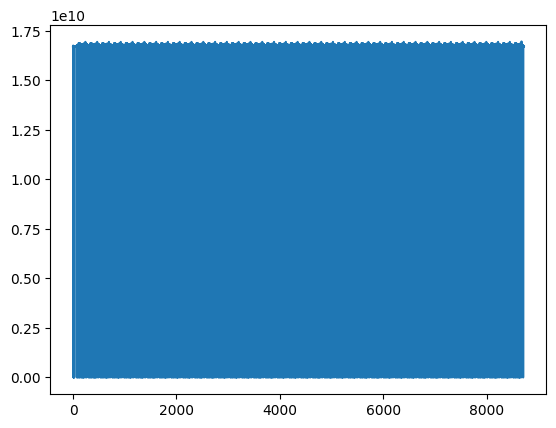

In [4]:
from diffusers import SD3Transformer2DModel

### User Inputs Below
name = "stabilityai/stable-diffusion-3.5-large-turbo"
log_dir = f"./log/SD35_large_turbo"
cfg_dim = 1 if "turbo" in name else 2
### User Inputs Above


print(
    f"[INFO] Before loading transformer, allocated memory {torch.cuda.memory_allocated(0)/1024**3}"
)
transformer = SD3Transformer2DModel.from_pretrained(
    name, subfolder="transformer", torch_dtype=torch.bfloat16
)
transformer = transformer.to("cuda:0")
print(
    f"[INFO] After loading transformer, allocated memory {torch.cuda.memory_allocated(0)/1024**3}"
)

latent_model_input = torch.rand([cfg_dim, 16, 128, 128], dtype=torch.bfloat16).to("cuda:0")
timestep = torch.rand([cfg_dim], dtype=torch.bfloat16).to("cuda:0")
prompt_embeds = torch.rand([cfg_dim, 333, 4096], dtype=torch.bfloat16).to("cuda:0")
pooled_prompt_embeds = torch.rand([cfg_dim, 2048], dtype=torch.bfloat16).to("cuda:0")
print(
    f"[INFO] Before running transformer, allocated memory {torch.cuda.memory_allocated(0)/1024**3}"
)
print(
    f"[INFO] Before running transformer, MAX allocated memory {torch.cuda.max_memory_allocated(0)/1024**3}"
)

with torch.profiler.profile(
    schedule=torch.profiler.schedule(wait=0, warmup=0.0, active=100, repeat=10),
    on_trace_ready=torch.profiler.tensorboard_trace_handler(log_dir),
    record_shapes=True,
    with_flops=True,
    profile_memory=True,
    with_stack=True,
) as prof:

    with torch.no_grad():
        noise_pred = transformer(
            hidden_states=latent_model_input,
            timestep=timestep,
            encoder_hidden_states=prompt_embeds,
            pooled_projections=pooled_prompt_embeds,
            joint_attention_kwargs=None,
            return_dict=False,
        )[0]
print(
    f"[INFO] After running transformer, allocated memory {torch.cuda.memory_allocated(0)/1024**3}"
)
print(
    f"[INFO] After running transformer, MAX allocated memory {torch.cuda.max_memory_allocated(0)/1024**3}"
)

peak, memory = display_memory_peak(log_dir)
plt.plot(memory)
del transformer
torch.cuda.empty_cache()
gc.collect()
torch.cuda.reset_max_memory_allocated()

print(
    f"[INFO] After removing transformer, allocated memory {torch.cuda.memory_allocated(0)/1024**3}"
)
print(
    f"[INFO] After removing transformer, MAX allocated memory {torch.cuda.max_memory_allocated(0)/1024**3}"
)

## PixArt

[INFO] Before loading transformer, allocated memory 0.011456012725830078
[INFO] After loading transformer, allocated memory 1.1586031913757324
[INFO] Before running transformer, allocated memory 1.160398006439209
[INFO] Before running transformer, MAX allocated memory 1.1629366874694824
[INFO] After running transformer, allocated memory 1.160398006439209
[INFO] After running transformer, MAX allocated memory 1.3732237815856934
Repeat #0:log/PixArt-Sigma-XL-2-1024-MS/inst-ahqiy-samsung-rdma-pool_2393905.1734636690594486863.pt.trace.json --> memory peak: 1.37 GB
[INFO] After removing transformer, allocated memory 0.01325082778930664
[INFO] After removing transformer, MAX allocated memory 0.01325082778930664


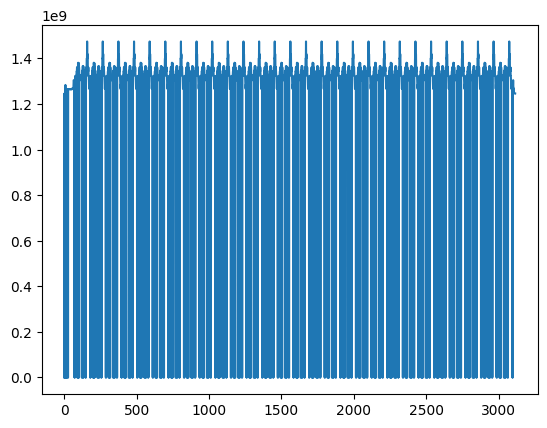

In [5]:
from diffusers import PixArtTransformer2DModel

### User Inputs Below
name = "PixArt-alpha/PixArt-Sigma-XL-2-1024-MS"  # or "PixArt-alpha/PixArt-Sigma-XL-2-512-MS"
log_dir = f"./log/{Path(name).name}"
### User Inputs Above

print(
    f"[INFO] Before loading transformer, allocated memory {torch.cuda.memory_allocated(0)/1024**3}"
)
transformer = PixArtTransformer2DModel.from_pretrained(
    name, torch_dtype=torch.float16, subfolder="transformer"
)
transformer = transformer.to("cuda:0")
print(
    f"[INFO] After loading transformer, allocated memory {torch.cuda.memory_allocated(0)/1024**3}"
)

latent_model_input = torch.rand([2, 4, 128, 128]).to("cuda:0", dtype=torch.float16)
prompt_embeds = torch.rand([2, 300, 4096]).to("cuda:0", dtype=torch.float16)
prompt_attention_mask = torch.rand([2, 300]).to("cuda:0", dtype=torch.float16)
current_timestep = torch.rand([2]).to("cuda:0", dtype=torch.float16)
added_cond_kwargs = {"resolution": None, "aspect_ratio": None}
print(
    f"[INFO] Before running transformer, allocated memory {torch.cuda.memory_allocated(0)/1024**3}"
)
print(
    f"[INFO] Before running transformer, MAX allocated memory {torch.cuda.max_memory_allocated(0)/1024**3}"
)

with torch.profiler.profile(
    schedule=torch.profiler.schedule(wait=0, warmup=0.0, active=100, repeat=10),
    on_trace_ready=torch.profiler.tensorboard_trace_handler(log_dir),
    record_shapes=True,
    with_flops=True,
    profile_memory=True,
    with_stack=True,
) as prof:

    with torch.no_grad():
        noise_pred = transformer(
            latent_model_input,
            encoder_hidden_states=prompt_embeds,
            encoder_attention_mask=prompt_attention_mask,
            timestep=current_timestep,
            added_cond_kwargs=added_cond_kwargs,
            return_dict=False,
        )[0]
print(
    f"[INFO] After running transformer, allocated memory {torch.cuda.memory_allocated(0)/1024**3}"
)
print(
    f"[INFO] After running transformer, MAX allocated memory {torch.cuda.max_memory_allocated(0)/1024**3}"
)

peak, memory = display_memory_peak(log_dir)
plt.plot(memory)
del transformer
torch.cuda.empty_cache()
gc.collect()
torch.cuda.reset_max_memory_allocated()

print(
    f"[INFO] After removing transformer, allocated memory {torch.cuda.memory_allocated(0)/1024**3}"
)
print(
    f"[INFO] After removing transformer, MAX allocated memory {torch.cuda.max_memory_allocated(0)/1024**3}"
)

## KOALA

[INFO] Before loading transformer, allocated memory 0.01325082778930664
[INFO] After loading transformer, allocated memory 2.217165470123291
[INFO] Before running transformer, allocated memory 2.2131810188293457
[INFO] Before running transformer, MAX allocated memory 2.2177534103393555
[INFO] After running transformer, allocated memory 2.2129368782043457
[INFO] After running transformer, MAX allocated memory 2.5120201110839844
Repeat #0:log/koala-lightning-1b/inst-ahqiy-samsung-rdma-pool_2393905.1734636705599478217.pt.trace.json --> memory peak: 2.51 GB
[INFO] After removing transformer, allocated memory 0.009022235870361328
[INFO] After removing transformer, MAX allocated memory 0.009022235870361328


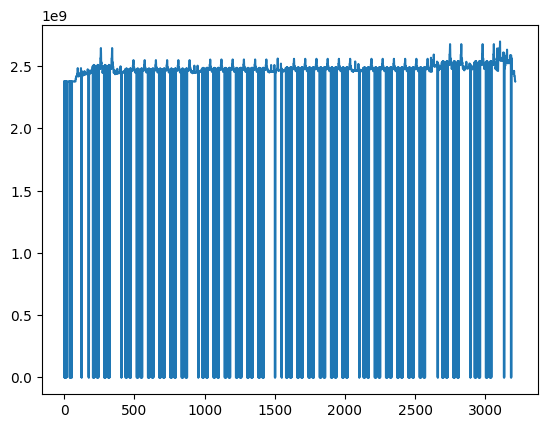

In [6]:
from diffusers import UNet2DConditionModel

### User Inputs Below
name = "etri-vilab/koala-lightning-1b"
log_dir = f"./log/{Path(name).name}"
### User Inputs Above

print(
    f"[INFO] Before loading transformer, allocated memory {torch.cuda.memory_allocated(0)/1024**3}"
)
transformer = UNet2DConditionModel.from_pretrained(
    name, subfolder="unet", torch_dtype=torch.float16
)
transformer = transformer.to("cuda:0")
print(
    f"[INFO] After loading transformer, allocated memory {torch.cuda.memory_allocated(0)/1024**3}"
)


latent_model_input = torch.rand([2, 4, 128, 128]).to("cuda:0", dtype=torch.float16)
t = torch.tensor(499).to("cuda:0", dtype=torch.float16)
prompt_embeds = torch.rand([2, 77, 2048]).to("cuda:0", dtype=torch.float16)
timestep_cond = None
cross_attention_kwargs = None
added_cond_kwargs = dict()
added_cond_kwargs["text_embeds"] = torch.rand([2, 1280]).to("cuda:0", dtype=torch.float16)
added_cond_kwargs["time_ids"] = torch.rand([2, 6]).to("cuda:0", dtype=torch.float16)
print(
    f"[INFO] Before running transformer, allocated memory {torch.cuda.memory_allocated(0)/1024**3}"
)
print(
    f"[INFO] Before running transformer, MAX allocated memory {torch.cuda.max_memory_allocated(0)/1024**3}"
)

with torch.profiler.profile(
    schedule=torch.profiler.schedule(wait=0, warmup=0.0, active=100, repeat=10),
    on_trace_ready=torch.profiler.tensorboard_trace_handler(log_dir),
    record_shapes=True,
    with_flops=True,
    profile_memory=True,
    with_stack=True,
) as prof:

    with torch.no_grad():
        noise_pred = transformer(
            latent_model_input,
            t,
            encoder_hidden_states=prompt_embeds,
            timestep_cond=timestep_cond,
            cross_attention_kwargs=cross_attention_kwargs,
            added_cond_kwargs=added_cond_kwargs,
            return_dict=False,
        )[0]
print(
    f"[INFO] After running transformer, allocated memory {torch.cuda.memory_allocated(0)/1024**3}"
)
print(
    f"[INFO] After running transformer, MAX allocated memory {torch.cuda.max_memory_allocated(0)/1024**3}"
)

peak, memory = display_memory_peak(log_dir)
plt.plot(memory)
del transformer
torch.cuda.empty_cache()
gc.collect()
torch.cuda.reset_max_memory_allocated()

print(
    f"[INFO] After removing transformer, allocated memory {torch.cuda.memory_allocated(0)/1024**3}"
)
print(
    f"[INFO] After removing transformer, MAX allocated memory {torch.cuda.max_memory_allocated(0)/1024**3}"
)

## Flux-schnell

[INFO] Before loading transformer, allocated memory 0.009022235870361328


Fetching 3 files: 100%|██████████| 3/3 [00:00<00:00, 36684.87it/s]


[INFO] After loading transformer, allocated memory 22.15810489654541
[INFO] Before running transformer, allocated memory 22.15998077392578
[INFO] Before running transformer, MAX allocated memory 22.16054630279541
[INFO] After running transformer, allocated memory 22.16022491455078
[INFO] After running transformer, MAX allocated memory 22.5684757232666
Repeat #0:log/Flux1_schnell/inst-ahqiy-samsung-rdma-pool_2393905.1734636740336503057.pt.trace.json --> memory peak: 22.57 GB
[INFO] After removing transformer, allocated memory 0.011142253875732422
[INFO] After removing transformer, MAX allocated memory 0.011142253875732422


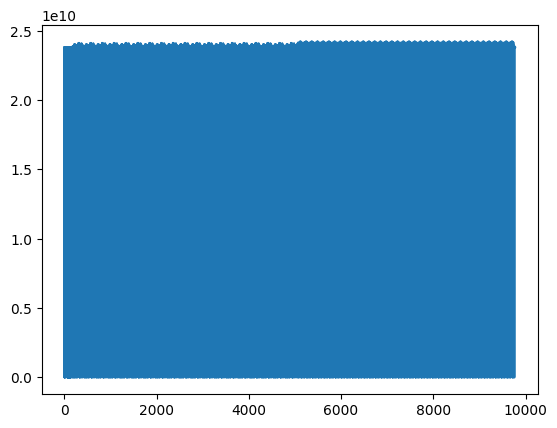

In [7]:
from diffusers import FluxTransformer2DModel

### User Inputs Below
name = "black-forest-labs/FLUX.1-schnell"
log_dir = f"./log/Flux1_schnell"
max_seq_length = 256 if "schnell" in name else 512
guidance = None if "schnell" in name else torch.tensor([3.5], dtype=torch.bfloat16).to("cuda:0")
cfg_dim = 1
### User Inputs Above

print(
    f"[INFO] Before loading transformer, allocated memory {torch.cuda.memory_allocated(0)/1024**3}"
)
transformer = FluxTransformer2DModel.from_pretrained(
    name, subfolder="transformer", torch_dtype=torch.bfloat16
)
transformer = transformer.to("cuda:0")
print(
    f"[INFO] After loading transformer, allocated memory {torch.cuda.memory_allocated(0)/1024**3}"
)

latents = torch.rand([cfg_dim, 4096, 64], dtype=torch.bfloat16).to("cuda:0")
timestep = torch.rand([cfg_dim], dtype=torch.bfloat16).to("cuda:0")
prompt_embeds = torch.rand([cfg_dim, max_seq_length, 4096], dtype=torch.bfloat16).to("cuda:0")
pooled_prompt_embeds = torch.rand([cfg_dim, 768], dtype=torch.bfloat16).to("cuda:0")
text_ids = torch.rand([max_seq_length, 3], dtype=torch.bfloat16).to("cuda:0")
latent_image_ids = torch.rand([4096, 3], dtype=torch.bfloat16).to("cuda:0")
print(
    f"[INFO] Before running transformer, allocated memory {torch.cuda.memory_allocated(0)/1024**3}"
)
print(
    f"[INFO] Before running transformer, MAX allocated memory {torch.cuda.max_memory_allocated(0)/1024**3}"
)

with torch.profiler.profile(
    schedule=torch.profiler.schedule(wait=0, warmup=0.0, active=100, repeat=10),
    on_trace_ready=torch.profiler.tensorboard_trace_handler(log_dir),
    record_shapes=True,
    with_flops=True,
    profile_memory=True,
    with_stack=True,
) as prof:

    with torch.no_grad():
        noise_pred = transformer(
            hidden_states=latents,
            timestep=timestep,
            guidance=guidance,
            pooled_projections=pooled_prompt_embeds,
            encoder_hidden_states=prompt_embeds,
            txt_ids=text_ids,
            img_ids=latent_image_ids,
            joint_attention_kwargs=None,
            return_dict=False,
        )[0]
print(
    f"[INFO] After running transformer, allocated memory {torch.cuda.memory_allocated(0)/1024**3}"
)
print(
    f"[INFO] After running transformer, MAX allocated memory {torch.cuda.max_memory_allocated(0)/1024**3}"
)

peak, memory = display_memory_peak(log_dir)
plt.plot(memory)
del transformer
torch.cuda.empty_cache()
gc.collect()
torch.cuda.reset_max_memory_allocated()

print(
    f"[INFO] After removing transformer, allocated memory {torch.cuda.memory_allocated(0)/1024**3}"
)
print(
    f"[INFO] After removing transformer, MAX allocated memory {torch.cuda.max_memory_allocated(0)/1024**3}"
)

## Flux-Dev

[INFO] Before loading transformer, allocated memory 0.011142730712890625


Fetching 3 files: 100%|██████████| 3/3 [00:00<00:00, 10979.85it/s]


[INFO] After loading transformer, allocated memory 22.179279804229736
[INFO] Before running transformer, allocated memory 22.18123435974121
[INFO] Before running transformer, MAX allocated memory 22.183186054229736
[INFO] After running transformer, allocated memory 22.18123435974121
[INFO] After running transformer, MAX allocated memory 22.611948013305664
Repeat #0:log/Flux1_dev/inst-ahqiy-samsung-rdma-pool_2393905.1734636771429677865.pt.trace.json --> memory peak: 22.61 GB
[INFO] After removing transformer, allocated memory 0.013097286224365234
[INFO] After removing transformer, MAX allocated memory 0.013097286224365234


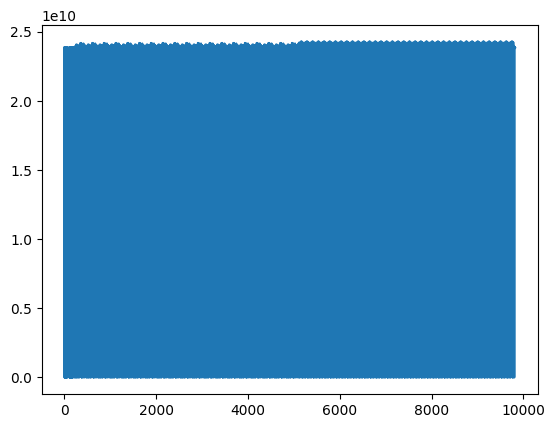

In [8]:
from diffusers import FluxTransformer2DModel

### User Inputs Below
name = "black-forest-labs/FLUX.1-dev"
log_dir = f"./log/Flux1_dev"
max_seq_length = 256 if "schnell" in name else 512
guidance = None if "schnell" in name else torch.tensor([3.5], dtype=torch.bfloat16).to("cuda:0")
cfg_dim = 1
### User Inputs Above

print(
    f"[INFO] Before loading transformer, allocated memory {torch.cuda.memory_allocated(0)/1024**3}"
)
transformer = FluxTransformer2DModel.from_pretrained(
    name, subfolder="transformer", torch_dtype=torch.bfloat16
)
transformer = transformer.to("cuda:0")
print(
    f"[INFO] After loading transformer, allocated memory {torch.cuda.memory_allocated(0)/1024**3}"
)

latents = torch.rand([cfg_dim, 4096, 64], dtype=torch.bfloat16).to("cuda:0")
timestep = torch.rand([cfg_dim], dtype=torch.bfloat16).to("cuda:0")
prompt_embeds = torch.rand([cfg_dim, max_seq_length, 4096], dtype=torch.bfloat16).to("cuda:0")
pooled_prompt_embeds = torch.rand([cfg_dim, 768], dtype=torch.bfloat16).to("cuda:0")
text_ids = torch.rand([max_seq_length, 3], dtype=torch.bfloat16).to("cuda:0")
latent_image_ids = torch.rand([4096, 3], dtype=torch.bfloat16).to("cuda:0")
print(
    f"[INFO] Before running transformer, allocated memory {torch.cuda.memory_allocated(0)/1024**3}"
)
print(
    f"[INFO] Before running transformer, MAX allocated memory {torch.cuda.max_memory_allocated(0)/1024**3}"
)

with torch.profiler.profile(
    schedule=torch.profiler.schedule(wait=0, warmup=0.0, active=100, repeat=10),
    on_trace_ready=torch.profiler.tensorboard_trace_handler(log_dir),
    record_shapes=True,
    with_flops=True,
    profile_memory=True,
    with_stack=True,
) as prof:

    with torch.no_grad():
        noise_pred = transformer(
            hidden_states=latents,
            timestep=timestep,
            guidance=guidance,
            pooled_projections=pooled_prompt_embeds,
            encoder_hidden_states=prompt_embeds,
            txt_ids=text_ids,
            img_ids=latent_image_ids,
            joint_attention_kwargs=None,
            return_dict=False,
        )[0]
print(
    f"[INFO] After running transformer, allocated memory {torch.cuda.memory_allocated(0)/1024**3}"
)
print(
    f"[INFO] After running transformer, MAX allocated memory {torch.cuda.max_memory_allocated(0)/1024**3}"
)

peak, memory = display_memory_peak(log_dir)
plt.plot(memory)
del transformer
torch.cuda.empty_cache()
gc.collect()
torch.cuda.reset_max_memory_allocated()

print(
    f"[INFO] After removing transformer, allocated memory {torch.cuda.memory_allocated(0)/1024**3}"
)
print(
    f"[INFO] After removing transformer, MAX allocated memory {torch.cuda.max_memory_allocated(0)/1024**3}"
)